<a href="https://colab.research.google.com/github/gocleanwater/AI-class/blob/main/week6/abalone_DL_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np

In [25]:
path = '/content/drive/MyDrive/Colab Notebooks/AI-class/week6/abalone.csv'
df = pd.read_csv(path)
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


# 0. Data 검사 단계

- 결측치 확인
- 이상치 확인
- 노이즈 제거

In [26]:
# 결측치 확인
df.isnull().sum()

,0
id,0
Sex,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0
Rings,0


/tmp/ipykernel_4648/1723185311.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Length", data=df, palette="Set3")


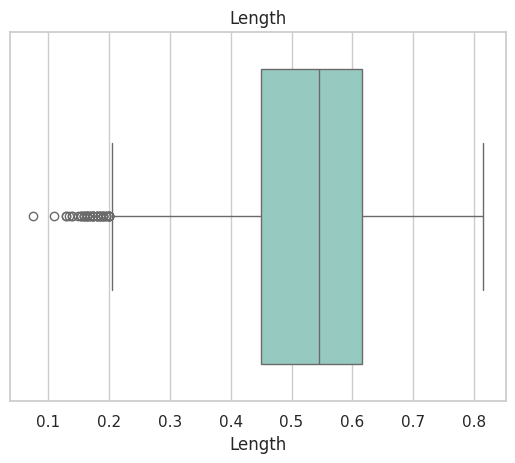

In [27]:
# 이상치 확인
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
sns.boxplot(x="Length", data=df, palette="Set3")
plt.title("Length")
plt.show()
# 이상치가 생각보다 많은데.. 어떻게 할지 모르겠음. 패스..

In [28]:
# 필요없는 Feature 제거
# id는 노이즈일 확률이 높으니 제거
df = df.drop('id', axis=1)

In [29]:
y = df['Rings']
print(y.value_counts())

Rings
9     689
10    634
8     568
11    487
7     391
12    267
6     259
13    203
14    126
5     115
15    103
16     67
17     58
4      57
18     42
19     32
20     26
3      15
21     14
23      9
22      6
24      2
27      2
1       1
29      1
26      1
2       1
25      1
Name: count, dtype: int64


In [30]:
X = df.drop('Rings', axis=1)
X.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


In [31]:
# 문자열이 들어있는 Sex 열 -> One-Hot Encoding하기 (문자열 삭제)
# pandas의 get_dummies()를 이용해 One-Hot Encoding을 진행한다.
# `drop_first=True`는 ML에서만 쓰고 DL에는 잘 안 씀.
X = pd.get_dummies(X, columns=['Sex'], dtype=int)
X.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Sex_F,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,0,0,1
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,0,0,1
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,1,0,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,0,0,1
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,0,1,0


# 1. 데이터 형태 변환 + One-Hot Encoding + 데이터 분할 + Scaling
## 에러
근데, `Rings`를 `Label(y)`로 잡아 One-Hot Encoding을 하여
```python
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0, stratify=y
)
```
를 하면
```
ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.
```
라는 에러메시지가 뜬다. 그 이유는 `stratify=y` 때문이다. 이유는 다음과 같다.
- **`stratify=y`**

  해당 코드는 `train_test_split()`를 할 때 **각 class 비율을 train/test에 비슷하게 유지**하도록 하는 코드이다.

  하지만, 특정 클래스(ex: 1,29)는 샘플이 1개뿐이라 **train과 test에 동시에 나눌 수 없기 때문이다.**
  > 예시:
  >
  >`Rings = 29` → 샘플 1개
  >
  >`test_size=0.2`면 train을 80%, test를 20%로 나눠야 하지만, 샘플이 1개이므로,
  >
  > - train: 0개
  > - test: 0개
  >
  >가 된다. 그런데, `stratify`는 각 클래스가 양쪽에 적절히 반영되길 원하니까 이 상황을 허용하지 않기 때문에 에러가 난다.

---

## 해결 방법들 (선택지)
### 1. Rare Class 처리
- 예시:
  - 1~4: `low`
  - 5~20: 각 클래스 유지
  - 21 이상: `high`

> 결과:
> - 1~4(low): 74개
> - 5: 115개
> - 6: 259개
> - ...(생략)...
> - 20: 26개
> - 21 이상(high): 36개

▶장점: 데이터를 크게 변경하지 않음. 그래서 class수가 많이 줄지 않음.

▷단점: imbalanced가 심함.
    
  ---
  
### 2. 구간 classification
- 예시
  - 0~7
  - 8~10
  - 11~13
  - 14 이상

▶장점: 훨씬 안정적임. Class Imbalance가 완화됨.

▷단점: 데이터가 많이 변함. 각 구간 내에서 분류가 불가

  ---

### 3. Ordinal Classification
**아예 One-Hot Encoding을 하지 않고**, **`Rings`를 순서형 분류**로 보는 것.
- 일반적인 Multi-class Classification인 경우에는 class들을 **One-Hot Encoding을 하여 서로 다른 독립 Class로 만든다.**
  
  이렇게 되면, 모델 입장에서는
  - 예측: 9, 실제: 10 : 틀림
  - 예측: 9, 실제: 29 : 틀림
- 하지만, Oridinal Classification인 경우에는 위 설명처럼 **One-Hot Encoding을 하지 않고 Label을 순서형 분류(순서가 있는 분류)로 본다.**

  이렇게 되면, 모델 입장에서는
  - 예측: 9, 실제: 10 : 가까움(거의 맞춤.)
  - 예측: 9, 실제: 29 : 엄청 멂(완전히 틀림.)
---
#### 가장 흔한 구현 방법: threshold(문턱, 임계값) 방식
예를 들어 class가 `1, 2, 3, 4, 5`라고 할 때:

**5개의 `softmax`대신 4개의 `sigmoid`를 사용한다.**

각 출력은 다음과 같다.
- `y > 1` 인가?
- `y > 2` 인가?
- `y > 3` 인가?
- `y > 4` 인가?

##### 예시:

1. 실제 label이 `3`이면,
  - `3 > 1` → 1
  - `3 > 2` → 1
  - `3 > 3` → 0
  - `3 > 4` → 0

  그래서 target은:
  ```python
  [1, 1, 0, 0]
  ```
2. 실제 label이 `5`일때,
```python
[1, 1, 1, 1]
```
3. 실제 label이 `1`일때,
```python
[0, 0, 0, 0]
```
이다.

- 즉, 각 샘플을 **누적(cumulative) binary target으로 변환**해서 **출력층을 `K-1`개의 sigmoid로 두는** 방식이다.

---

> **위에 설명의 이해를 위한 softmax, sigmoid 활성화 함수 개념 쉽게 정리**
>   - `softmax`란?
>
>     출력값이 다음과 같다고 가정해보자.
>     $$
>     [2.0, 1.0, 0.1]
>     $$
>     `softmax`를 거치면 다음과 같이 된다.
>     $$
>     [0.66, 0.24, 0.10]
>     $$
>     특징은 다음과 같다.
>       - 전부 0~1 사이의 값
>       - 합이 1
>       - **서로 경쟁**한다는 느낌
>   
>     즉, **3개 중 하나일 확률**로 값이 나온다. (`A`일 확률이 높고, 나머지는 아니다.) (그래서 **다중 분류에 적합**)
>
>   - `sigmoid`란?
>
>     출력이 다음과 같다고 가정해보자.
>     $$
>     [0.8, 0.7, 0.9]
>     $$
>     특징은 다음과 같다.
>       - 전부 0~1 사이의 값
>       - **서로 독립적**이라는 느낌
>   
>     즉, **각 클래스가 될 확률을 따로 구한다.** (`A`, `B`, `C` 모두 가능성이 있다.) (그래서 **이진 분류에 적합**)



In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.utils.class_weight import compute_class_weight

import seaborn as sns
import matplotlib.pyplot as plt

## A. `Rare Class` 처리
- `1, 2, 3, 4` → `4`로 통합
- `5 ~ 20`: 각 클래스 유지
- `21 이상`: → `21`로 통합

In [33]:
y_cls = df["Rings"].clip(lower=4, upper=21)
print(y_cls.value_counts().sort_index())

Rings
4      74
5     115
6     259
7     391
8     568
9     689
10    634
11    487
12    267
13    203
14    126
15    103
16     67
17     58
18     42
19     32
20     26
21     36
Name: count, dtype: int64


In [34]:
Y = pd.get_dummies(y_cls).values

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0, stratify=y_cls
)

# validation을 여기서 미리 나눠주고, stratify=y_train으로 균등하게 나눠줌.
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=0, stratify=y_train,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(2672, 10) (669, 10) (836, 10)
(2672, 18) (669, 18) (836, 18)


# A-2. 딥러닝 모델 생성, 학습, 평가

In [35]:
import tensorflow as tf

layers = tf.keras.layers
models = tf.keras.models

model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)), # 입력층 shape는 입력 열 개수(현재 9)
    layers.Dense(128, activation='relu'), # 은닉층(64개)
    layers.Dropout(0.3), # Dropout으로 랜덤하게 뉴런의 30% 을 제외시킴(끔). overfitting을 막기 위함.
    layers.Dense(64, activation='relu'), # 은닉층(32개)
    layers.Dropout(0.2),
    layers.Dense(y_train.shape[1], activation='softmax') #출력층 (y_train.shape[1]만큼 출력함.(현재 18))
    # multi-class classification이므로 activation이 softmax
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # One-Hot Encoding이므로 loss function이 categorial_crossentropy
    metrics=['accuracy'] # Classification이므로 metrics가 accurancy이다.
)

# 과잉적합을 막기 위한 코드라고 함.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

# 이건 이번에 챗지피티한테 물어보니까 Optimizer(경사하강법)의 학습률을 줄이는 용도라고 한다!!!
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr], # callback으로 early_stopping()과 reduce_lr()를 넣어줌
    verbose=1
)

Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1999 - loss: 2.4907 - val_accuracy: 0.2436 - val_loss: 2.2343 - learning_rate: 0.0010
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2272 - loss: 2.2081 - val_accuracy: 0.2706 - val_loss: 2.1132 - learning_rate: 0.0010
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2459 - loss: 2.1144 - val_accuracy: 0.2765 - val_loss: 2.0659 - learning_rate: 0.0010
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2418 - loss: 2.0751 - val_accuracy: 0.2720 - val_loss: 2.0295 - learning_rate: 0.0010
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2500 - loss: 2.0430 - val_accuracy: 0.2915 - val_loss: 2.0107 - learning_rate: 0.0010
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2496 - loss: 2.0276 - val_accuracy: 0.2810 - val_loss: 1.9914 - learning_rate: 0.0010
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2605 - loss: 2.0097 - val_acc

# A-3. 예측 및 평가

In [36]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

label_names = [str(i) for i in range(4, 22)]

print(classification_report(y_test_class, y_pred_class, target_names=label_names))
print(confusion_matrix(y_test_class, y_pred_class))

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           4       0.37      0.47      0.41        15
           5       0.23      0.13      0.17        23
           6       0.38      0.29      0.33        52
           7       0.33      0.45      0.38        78
           8       0.35      0.39      0.37       114
           9       0.28      0.41      0.33       138
          10       0.19      0.20      0.19       127
          11       0.27      0.36      0.31        98
          12       0.20      0.04      0.06        53
          13       0.18      0.22      0.20        41
          14       0.00      0.00      0.00        25
          15       0.00      0.00      0.00        21
          16       0.30      0.23      0.26        13
          17       0.00      0.00      0.00        12
          18       0.00      0.00      0.00         8
          19       0.00      0.00      0.00         6
          20       0.00      0.00      0.0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# A-4. 학습 과정 시각화

In [37]:
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(loss) + 1)

## A-4-1. `Rare Class` 처리 손실 그래프

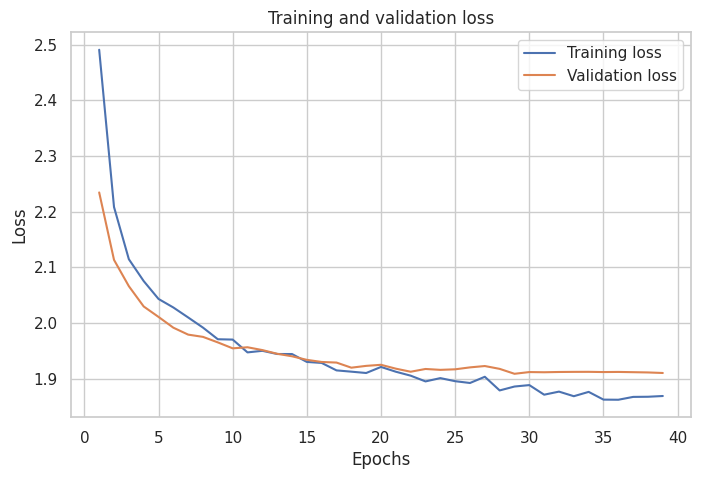

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## A-4-2. `Rare Class` 처리 정확도 그래프

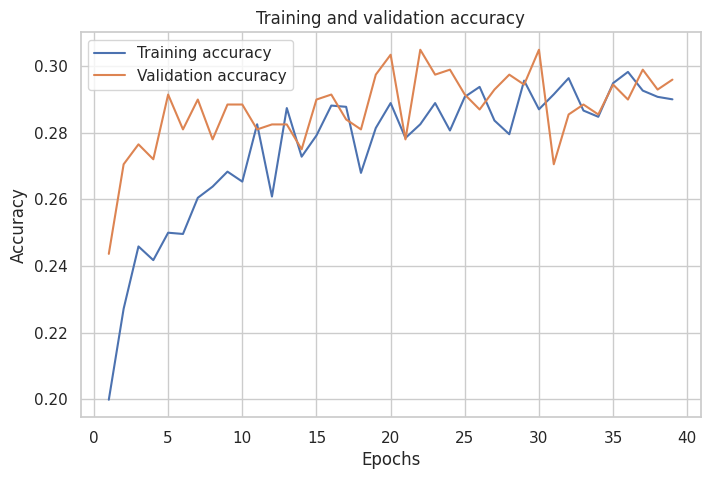

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs, val_acc, label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# A-5. `Rare Class` 처리 결과
- Accuracy가 0.28이라니..  성능이 확실히 떨어진다.
- 그 이유는 명확하다. Imbalanced Data이며 Class가 18개로 너무 많기 때문이다.

---
---

# B. `Rare Class 처리 + Ordinal Classification`
## `Rare Class`: 처리는 위와 같은 방식을 이용한다.
- `1, 2, 3, 4` → `4`로 통합
- `5 ~ 20`: 각 클래스 유지
- `21 이상`: → `21`로 통합

In [40]:
# 앞에서 Rare class를 처리함. 그러니 생략
print(y_cls.value_counts().sort_index())
y = y_cls.values.astype(int)

label_min = y.min()          # 4
label_max = y.max()          # 21
num_classes = label_max - label_min + 1   # 18

# 4~21 -> 0~17 로 변환
y_encoded = y - label_min

def to_ordinal_targets(y, num_classes):
    y = np.asarray(y).astype(int)
    return (y[:, None] > np.arange(num_classes - 1)).astype(np.float32)

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_encoded, test_size=0.2, random_state=0, stratify=y_encoded
)

X_train, X_val, y_train_raw, y_val_raw = train_test_split(
    X_train, y_train_raw, test_size=0.2, random_state=0, stratify=y_train_raw
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

y_train = to_ordinal_targets(y_train_raw, num_classes)
y_val = to_ordinal_targets(y_val_raw, num_classes)
y_test = to_ordinal_targets(y_test_raw, num_classes)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

Rings
4      74
5     115
6     259
7     391
8     568
9     689
10    634
11    487
12    267
13    203
14    126
15    103
16     67
17     58
18     42
19     32
20     26
21     36
Name: count, dtype: int64
(2672, 10) (669, 10) (836, 10)
(2672, 17) (669, 17) (836, 17)


## B-0. Sample Weight 만들기
- 챗지피티가 제안하는데, 뭔지 모르겠음. 했는데, 성능이 더 떨어지면 뺄 예정.
- 뭔지 모르겠음...

In [41]:
# classes = np.unique(y_train_raw)
# weights = compute_class_weight(
#     class_weight="balanced",
#     classes=classes,
#     y=y_train_raw
# )
# class_weight_dict = {int(cls): float(w) for cls, w in zip(classes, weights)}

# sample_weight_train = np.array(
#     [class_weight_dict[int(label)] for label in y_train_raw],
#     dtype=np.float32
# )

# print(class_weight_dict)

## B-2. 딥러닝 모델 생성, 학습, 평가

In [42]:
label_min = int(y.min())
label_max = int(y.max())
num_classes = int(label_max - label_min + 1)

layers = tf.keras.layers
models = tf.keras.models

model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes - 1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.BinaryAccuracy(name='bin_acc')]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    # sample_weight=sample_weight_train,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - bin_acc: 0.8469 - loss: 0.4068 - val_bin_acc: 0.8966 - val_loss: 0.2636 - learning_rate: 0.0010
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - bin_acc: 0.8939 - loss: 0.2675 - val_bin_acc: 0.9027 - val_loss: 0.2314 - learning_rate: 0.0010
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - bin_acc: 0.9002 - loss: 0.2470 - val_bin_acc: 0.9097 - val_loss: 0.2179 - learning_rate: 0.0010
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - bin_acc: 0.9044 - loss: 0.2311 - val_bin_acc: 0.9104 - val_loss: 0.2083 - learning_rate: 0.0010
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - bin_acc: 0.9069 - loss: 0.2233 - val_bin_acc: 0.9143 - val_loss: 0.2007 - learning_rate: 0.0010
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - bin_acc: 0.9090 - loss: 0.2182 - val_bin_acc: 0.9150 - val_loss: 0.1986 - learning_rate: 0.0010
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - bin_acc: 0.9096 - loss: 0.2149 - val_bin_acc: 0.9162 

# B-3. 예측 및 평가

- 여기서 조금 **다른 점**이 보인다.
- 바로 평가하는 것이 아니라, **`sigmoid` 여러 개를 다시 `ordinal class`로 복원**한다.

## 밑 코드 해설
- `y_pred_prob = model.predict(X_test)`
  
  모델이 테스트 데이터에 대해 예측한 값을 받는다.
- 그래서, 현재 모델의 `predict` 출력층은 **`num_classes - 1`개의 sigmoid**이다.

  예는 다음과 같다.
  ```python
  [0.91, 0.83, 0.65, 0.22, 0.10, ...]
  ```
  이는 다음과 같이 해석한다.
  - 첫 번째 출력: y > 0 일 확률
  - 두 번째 출력: y > 1 일 확률
  - 세 번째 출력: y > 2 일 확률
  - ...
  
  그럼으로, **threshold가 0.5**라고 하면, 위 예시는 0보다 크고, 1보다 크고, 2보다 크지만, 3보다 크지 않으므로 **3으로 예상할 수 있다.**

- 위 역할을 `y_pred_raw = (y_pred_prob > 0.5).sum(axis=1)` 코드가 한다.

  - `(y_pred_prob > 0.5)`를 통해 출력이 다음과 같이 변한다.
  ```python
  [True, True, True, False, False]
  ```
  가 된다.
  - `.sum(axis=1)`로 True(1)의 개수를 센다.
  ```python
  [True, True, True, False, False] -> 3
  ```
  그래서,
  이렇게 변한다.
  - class 0 → `[0, 0, 0, 0, ...]`
  - class 1 → `[1, 0, 0, 0, ...]`
  - class 2 → `[1, 1, 0, 0, ...]`
  - class 3 → `[1, 1, 1, 0, ...]`

  즉, `0.5 초과인 출력의 개수 = 예측 class index`이다.

  - 그리고, 학습할 때는 바꿨던 `Rings` 값인 4-21을 0-17로 바꿔서 사용했기에 다시 바꿔준다.
  ```python
  y_pred_label = y_pred_raw + label_min
  y_test_label = y_test_raw + label_min
  ```

---

## Classification인데 평가 지표에 왠 MAE랑 Binary Accuracy는 또 뭔가??
### 왜 MAE인가??
- 일반적인 Classification이라면, **Class를 맞추지 못하면 바로 땡!** 이기 때문에 **MAE와 같은 오차를 보는 평가지표**는 필요가 없다.

- 하지만, Ordinal Classification인 경우 마치 Reggresion처럼 경우에 따라 오차가 존재한다. 예시를 들면

  `실제: 10, 예측: 9` 일 때는 `실제: 10, 예측: 21`와 같이 **땡으로 판단하는 것은 정보 손실이 크다.** 왜냐하면 **전자는 거의 맞춘 것**이고, **후자는 완전히 틀린 것**이기 때문이다.

  이럴 때는 단순 Accuracy로는 부족하고 **얼마나 틀렸는지(오차)** 도 보기 때문에 `MAE`를 본다.

### Binary Accuracy는 또 뭔가? Acurracy와 다른 점은??
- Binary Accuracy는 **출력 벡터 각 칸이 맞았는지**를 본다.

  예를 들어, 정답이
  ```python
  [1, 1, 1, 0, 0]
  ```
  일때, 예측이
  ```python
  [1, 1, 0, 0, 0]
  ```
  이면 5칸 중 4칸 맞았으니까 Binary Accuracy는 `0.8`이다.

- Accuracy는 그래서 **최종 Class를 맞췄는지**를 본다.

   예를 들어, 정답이
  ```python
  [1, 1, 1, 0, 0]
  ```
  여서 정답 Class가 3이고, 예측이
  ```python
  [1, 1, 0, 0, 0]
  ```
  여서 예측 Class거 2이면 Accuracy는 `0`이다.


In [43]:
from sklearn.metrics import accuracy_score, mean_absolute_error

y_pred_prob = model.predict(X_test)

# 0~17 범위의 ordinal class 예측
y_pred_raw = (y_pred_prob > 0.5).sum(axis=1)

# 다시 원래 Rings 범위(4~21)로 복원
y_pred_label = y_pred_raw + label_min
y_test_label = y_test_raw + label_min

print("Accuracy:", accuracy_score(y_test_label, y_pred_label))
print("MAE:", mean_absolute_error(y_test_label, y_pred_label))
print("Within-1 Accuracy:", np.mean(np.abs(y_test_label - y_pred_label) <= 1))

print(classification_report(y_test_label, y_pred_label))
print(confusion_matrix(y_test_label, y_pred_label))

metric = tf.keras.metrics.BinaryAccuracy(threshold=0.5)
metric.update_state(y_test, y_pred_prob)

print("Binary Accuracy:", metric.result().numpy())

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.26674641148325356
MAE: 1.4186602870813396
Within-1 Accuracy: 0.6686602870813397
              precision    recall  f1-score   support

           4       0.43      0.40      0.41        15
           5       0.17      0.09      0.11        23
           6       0.36      0.27      0.31        52
           7       0.37      0.40      0.39        78
           8       0.35      0.34      0.35       114
           9       0.29      0.34      0.31       138
          10       0.23      0.31      0.26       127
          11       0.27      0.32      0.29        98
          12       0.17      0.11      0.14        53
          13       0.09      0.10      0.10        41
          14       0.04      0.04      0.04        25
          15       0.00      0.00      0.00        21
          16       0.20      0.08      0.11        13
          17       0.50      0.08      0.14        12
          18       0.00      0.00      0.00         8
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# B-4. 학습 과정 시각화

In [44]:
loss = history.history['loss']
val_loss = history.history['val_loss']
bin_acc = history.history['bin_acc']
val_bin_acc = history.history['val_bin_acc']

epochs = range(1, len(loss) + 1)

## B-4-1. `Rare Class 처리 + Ordinal Classification` 손실 그래프

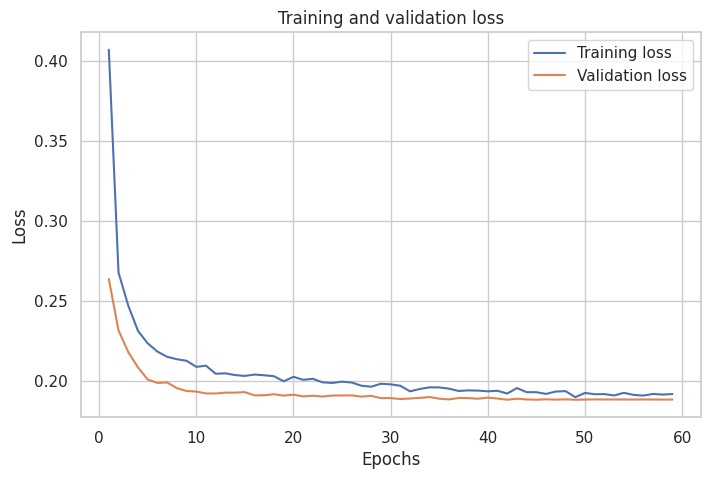

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## B-4-2. `Rare Class 처리 + Ordinal Classification` Binary Accuracy 그래프

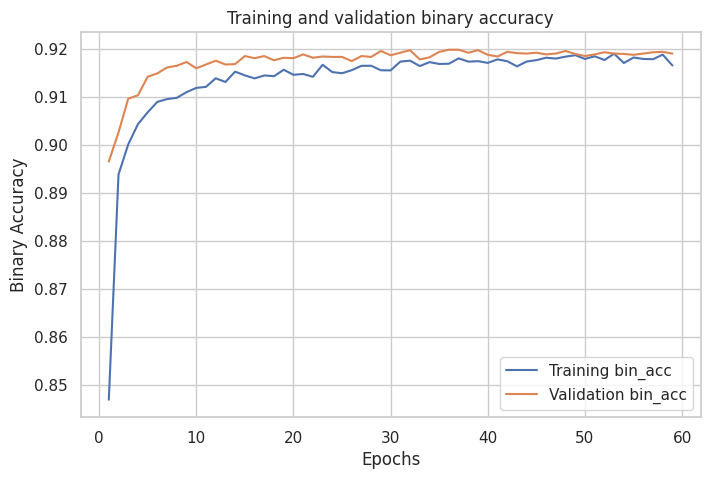

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, bin_acc, label='Training bin_acc')
plt.plot(epochs, val_bin_acc, label='Validation bin_acc')
plt.title('Training and validation binary accuracy')
plt.xlabel('Epochs')
plt.ylabel('Binary Accuracy')
plt.legend()
plt.show()

# B-5. Rare Class 처리 결과
- Accuracy 자체는 0.27로 낮다.
- 하지만, Binary Accuracy는 0.92로 높은 것을 알 수 있다!!!

#